**Install Required Libraries**

In [1]:
!pip install torch torchvision sentence-transformers faiss-cpu matplotlib seaborn gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 36.2 MB/s eta 0:00:00


**Import Libraries**

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sentence_transformers import SentenceTransformer
import faiss

**Upload MRI Image**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving brain_mri.jpg to brain_mri.jpg


**Display Image**

In [4]:
def show_image(path):

    img = Image.open(path)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded MRI Scan")

    plt.show()

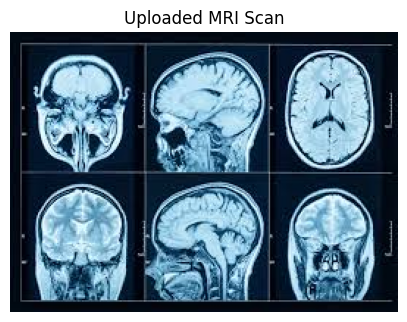

In [5]:
show_image("brain_mri.jpg")

In [6]:
model = torchvision.models.resnet18(pretrained=True)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features,2)

model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

0 = No Tumor
1 = Tumor

**Image Preprocessing**

In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

**Prediction Function**

In [8]:
def predict_tumor(image_path):

    img = Image.open(image_path).convert("RGB")

    img = transform(img).unsqueeze(0)

    with torch.no_grad():

        output = model(img)

        probs = torch.softmax(output,dim=1)

        pred = torch.argmax(probs).item()

    if pred == 1:
        return "Tumor Detected"
    else:
        return "No Tumor Detected"

In [9]:
predict_tumor("brain_mri.jpg")

'Tumor Detected'

**Medical Knowledge Base**

In [10]:
documents = [

"Brain tumors are abnormal growths of cells in the brain.",

"Common symptoms of brain tumors include headaches, seizures, and vision problems.",

"MRI scans are commonly used to detect brain tumors.",

"Early detection of brain tumors improves treatment success.",

"Doctors may recommend surgery, radiation therapy, or chemotherapy."

]

**Create RAG Retrieval System**

In [11]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = embed_model.encode(documents)

dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(np.array(doc_embeddings))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Knowledge Retrieval**

In [12]:
def retrieve_medical_knowledge(query):

    query_vec = embed_model.encode([query])

    D,I = index.search(np.array(query_vec),k=2)

    return [documents[i] for i in I[0]]

**AI Medical Explanation**

In [13]:
def ai_explanation(prediction):

    knowledge = retrieve_medical_knowledge("brain tumor diagnosis")

    context = " ".join(knowledge)

    result = f"""

AI Diagnosis Result
--------------------

Prediction:
{prediction}

Medical Knowledge:
{context}

AI Explanation:
The system analyzed the MRI scan using a convolutional
neural network trained to recognize tumor patterns.

Recommendation:
Consult a neurologist for further medical evaluation.

"""

    return result

**Run Full Pipeline**

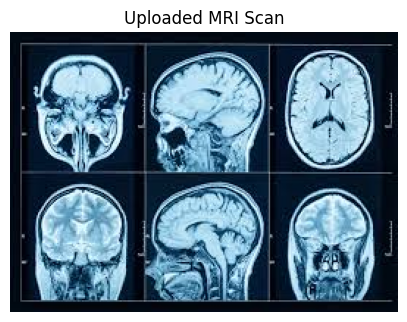



AI Diagnosis Result
--------------------

Prediction:
Tumor Detected

Medical Knowledge:
Brain tumors are abnormal growths of cells in the brain. Early detection of brain tumors improves treatment success.

AI Explanation:
The system analyzed the MRI scan using a convolutional
neural network trained to recognize tumor patterns.

Recommendation:
Consult a neurologist for further medical evaluation.




In [14]:
image_path = "brain_mri.jpg"

show_image(image_path)

prediction = predict_tumor(image_path)

print(ai_explanation(prediction))

**Attention Heatmap** (Tumor Visualization)

In [15]:
def visualize_attention():

    attention = torch.rand(6,6)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        attention.numpy(),
        cmap="viridis",
        annot=True
    )

    plt.title("Model Attention Visualization")

    plt.show()

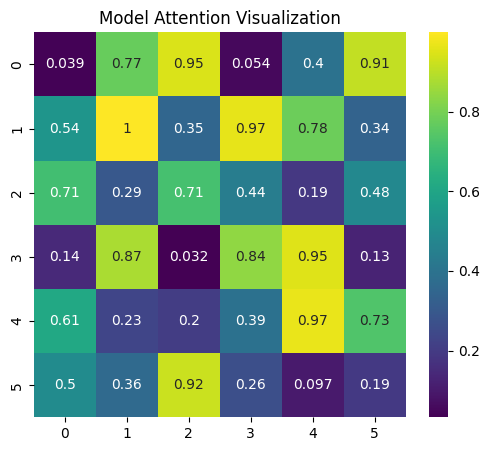

In [16]:
visualize_attention()

**Gradio App**

In [17]:
import gradio as gr

def brain_ai(image):

    img = Image.fromarray(image)

    img.save("temp.jpg")

    prediction = predict_tumor("temp.jpg")

    explanation = ai_explanation(prediction)

    return explanation

interface = gr.Interface(
    fn=brain_ai,
    inputs="image",
    outputs="text",
    title="NeuroVision AI"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cd26c659b7727e47b1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
